# Table of contents

* **Introduction**
* **Objective**
* **Long Short-Term Memory (LSTM) Foundations**
* **Data Dictionary**
* **Pipeline Overview**
* **Approach**
* **Setup Environments**
* **Data Loading**
* **Exploratory Data Analysis (EDA)**
* **Features Engineering**
* **Model Training**
    * Model Architecture and Model Building (Keras)
    * Model training (Keras)
    * Model Architecture and Model Building (TensorFlow custom functions)
    * Model training (TensorFlow custom functions)
* **Model Evaluation**
* **Conclusion**
* **References**

# Introduction

This tutorial details the development, training, and evaluation of a Long Short-Term Memory (LSTM) neural network specifically tailored for multivariate time series forecasting in a financial context. The project utilizes real-world stock price data for the EQIX asset. The primary modeling approach involves building an LSTM network in TensorFlow and Keras. A core focus is demonstrating modularity by implementing a custom Keras layer named CustomLSTMStack. This layer encapsulates complex sequence processing logic, providing a clean, reusable component. The overall goal is to predict the next day's key financial features—open, close, low, high, and volume—based on a sliding window of historical observations, adhering strictly to time series best practices throughout the pipeline.

# Objective

The core objectives driving this project include:

- Predictive Modeling: To accurately forecast the subsequent time step's five stock price features (open, close, low, high, volume) using a fixed-length sequence of prior days as input.
- Keras Customization: To design and implement a custom Keras Layer (`CustomLSTMStack`). This demonstrates how to abstract repeated neural network patterns—such as a stack of recurrent layers and normalization—into a single, configurable component.
- Utility Function Development: To create specialized, reusable functions necessary for time series data preparation, including sequence generation, prediction execution, advanced plotting, and robust metric calculation.
- Comprehensive Evaluation: To rigorously assess model performance using standard regression metrics like Mean Squared Error (MSE) and, critically, a financial-specific metric: the directional sign prediction accuracy (comparing the actual price change, $y_{\text{close}} - y_{\text{open}}$, against the predicted change).

# Long Short-Term Memory (LSTM) Foundations

LSTMs are a specialized type of Recurrent Neural Network (RNN) designed to overcome the limitations of standard RNNs when processing sequences, particularly their inability to capture long-range dependencies. LSTMs effectively solve the vanishing gradient problem, allowing the network to retain information over extended periods.

**The Vanishing Gradient Problem**

In standard RNNs, information is passed through a sequence of time steps. During backpropagation, the gradients (error signals) must be multiplied through many layers. If the activation function's derivative is small (e.g., in the saturated regions of the $\text{sigmoid}$ or $\text{tanh}$ functions), the gradients shrink exponentially as they propagate backward through time. This phenomenon, known as the vanishing gradient problem, causes the network's weights to update negligibly for early inputs in a long sequence, making it impossible for the model to "remember" distant information. LSTMs address this by introducing a dedicated cell state and gate mechanisms.

**Primary applications include:**

- Natural Language Processing (NLP): Machine translation, sentiment analysis, language modeling, and text generation.
- Time Series Forecasting: Predicting stock prices, weather patterns, electricity demand, and sensor readings.
- Speech Recognition: Processing sequential audio features.Advanced LSTM Architectures

**Stacked LSTMs**

This involves placing multiple LSTM layers on top of each other. The output hidden state ($\mathbf{h}_t$) of the lower layer serves as the input ($\mathbf{x}_t$) to the layer directly above it. Stacking increases the model's capacity to learn higher-level temporal representations from the data. For the output of any intermediate layer to be correctly consumed by the next layer, it must be configured to return the full sequence of hidden states, not just the final state.

**Bidirectional LSTMs (Bi-LSTMs)**

A Bi-LSTM processes the input sequence in two directions: one layer processes the sequence from beginning to end (forward), and a second layer processes the sequence from end to beginning (backward). The hidden states from both layers are typically concatenated to form the final output. This architecture is particularly useful when the context of the future is as important as the context of the past (e.g., in sequence labeling or machine translation).

**Sequence-to-Sequence (Seq2Seq) Models**

Seq2Seq models, often built with LSTMs, consist of two parts: an Encoder and a Decoder. The Encoder processes the input sequence and compresses the relevant information into a final context vector (the final cell state and hidden state). The Decoder then takes this context vector and unrolls it to generate a new output sequence (e.g., translating a sentence from one language to another).

**Key Advantages**

- Long-Term Memory: LSTMs effectively mitigate the vanishing gradient problem, allowing them to learn and retain relationships between data points separated by hundreds of time steps.
- Controllable Information Flow: The gate mechanisms provide explicit control over when to forget old information, when to accept new information, and what to output, making the learning process highly targeted.
- State Persistence: The Cell State maintains a persistent memory stream, ensuring that information that has already been deemed important is not erased by subsequent, less relevant inputs.

Understanding these internal mechanisms—the Cell State, and the Forget, Input, and Output gates—is crucial to grasping why LSTMs became the dominant model for sequential data before the rise of the Transformer architecture.

**The LSTM Structure**

Instead of a single, simple activation function, the LSTM cell is composed of four interacting components: a Cell State and three controlling Gates.

**1. The Cell State ($\mathbf{C}_t$)**

The Cell State is the core of the LSTM. It acts as a horizontal "conveyor belt" running through the entire sequence of cells, carrying relevant information across time steps. The Cell State is designed to carry information with minimal alteration, allowing it to preserve long-term dependencies. New information is added to it, and old information is removed from it, all under the strict regulation of the gates.

**2. Gate Mechanisms**

Gates are structures composed of a sigmoid neural network layer and a pointwise multiplication operation. The sigmoid layer outputs values between 0 and 1, describing how much of each component should be allowed to pass through. A value close to 0 means "let nothing pass," and a value close to 1 means "let everything pass."
- a. Forget Gate ($\mathbf{f}_t$)The Forget Gate decides which information in the old Cell State ($\mathbf{C}_{t-1}$) should be discarded. It takes the previous hidden state ($\mathbf{h}_{t-1}$) and the current input ($\mathbf{x}_t$) and outputs a vector of values between 0 and 1. Multiplying this vector by $\mathbf{C}_{t-1}$ determines which parts of the old memory are retained.

$$\mathbf{f}_t = \sigma(\mathbf{W}_f \cdot [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_f)$$

- b. Input Gate ($\mathbf{i}_t$) and Candidate Cell State ($\tilde{\mathbf{C}}_t$)The Input Gate decides which new information from the current input will be stored in the Cell State. This process is two-fold:
    - The Input Gate ($\mathbf{i}_t$) (sigmoid layer) determines which values in the current input to update.
    - The Candidate Cell State ($\tilde{\mathbf{C}}_t$) (tanh layer) creates a vector of new candidate values that could be added to the state.

$$\mathbf{i}_t = \sigma(\mathbf{W}_i \cdot [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_i)$$

$$\tilde{\mathbf{C}}_t = \tanh(\mathbf{W}_C \cdot [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_C)$$

- c. Updating the Cell StateThe previous Cell State ($\mathbf{C}_{t-1}$) is updated to the new Cell State ($\mathbf{C}_t$). First, the old state is multiplied by $\mathbf{f}_t$ (forgetting unneeded information). Then, the candidate values $\tilde{\mathbf{C}}_t$ are scaled by $\mathbf{i}_t$ (selecting new information) and added to the state.

$$\mathbf{C}_t = \mathbf{f}_t \odot \mathbf{C}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{C}}_t$$

- d. Output Gate ($\mathbf{o}_t$): The Output Gate determines what part of the Cell State will be visible as the new hidden state ($\mathbf{h}_t$).
    - The Output Gate ($\mathbf{o}_t$) (sigmoid layer) determines which parts of the cell state contribute to the output.
    - The new Cell State ($\mathbf{C}_t$) is run through a $\tanh$ function (to squash the values between -1 and 1).
    - The result is multiplied by the output of the sigmoid gate to produce the Hidden State ($\mathbf{h}_t$).
    
$$\mathbf{o}_t = \sigma(\mathbf{W}_o \cdot [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_o)$$
        
$$\mathbf{h}_t = \mathbf{o}_t \odot \tanh(\mathbf{C}_t)$$

The Hidden State ($\mathbf{h}_t$) is used for two purposes: it is the output for the current time step and it is passed to the next LSTM cell.Applications and ArchitecturesUse CasesLSTMs excel in domains where the context of past data is critical to understanding the present or predicting the future. 

# Data Dictionary

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Field Name</th>
    <th class="tg-7zrl">Description</th>
    <th class="tg-7zrl">Data Type</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">date</td>
    <td class="tg-7zrl">The date range for each data entry. This appears to be a combined string of start and end dates.</td>
    <td class="tg-7zrl">Text</td>
  </tr>
  <tr>
    <td class="tg-7zrl">DateTimeCount</td>
    <td class="tg-7zrl">The count of DateTime entries within the specified date range.</td>
    <td class="tg-7zrl">Numeric (Integer)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">symbol</td>
    <td class="tg-7zrl">An identifier or code, possibly for a financial instrument or category.</td>
    <td class="tg-7zrl">Text</td>
  </tr>
  <tr>
    <td class="tg-7zrl">open</td>
    <td class="tg-7zrl">The opening price/value for a given period.</td>
    <td class="tg-7zrl">Numeric (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">close</td>
    <td class="tg-7zrl">The closing price/value for a given period.</td>
    <td class="tg-7zrl">Numeric (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">low</td>
    <td class="tg-7zrl">The lowest price/value recorded within a given period.</td>
    <td class="tg-7zrl">Numeric (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">high</td>
    <td class="tg-7zrl">The highest price/value recorded within a given period.</td>
    <td class="tg-7zrl">Numeric (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">volume</td>
    <td class="tg-7zrl">The trading volume (number of units traded) within a given period.</td>
    <td class="tg-7zrl">Numeric (Integer)</td>
  </tr>
</tbody></table>

**[Dataset Link](https://www.kaggle.com/datasets/dgawlik/nyse)**

# Pipeline Overview

The forecasting project is structured into ten sequential stages designed to maintain data integrity and optimize model training. The process begins with data preparation and progresses through architecture design, training optimization, and thorough evaluation. The stages are: Data Loading and Initial Exploration, Chronological Train-Validation-Test Data Splitting, Feature Engineering, Data Normalization using Min-Max Scaling, Sequence Generation via the Sliding Window method, Tensor Conversion for Keras input, Model Architecture Design (incorporating the custom layer), Model Compilation and Training with Early Stopping, Prediction Generation across all three datasets, Visualization of Time Series Forecasts, and final Evaluation using all defined metrics.

# Approach

**Preprocessing Pipeline Approach**

The preprocessing phase enforces the temporal structure of the data and prepares it for the recurrent neural network.

**Data Selection and Split**

The initial data is filtered down to a single stock symbol (EQIX). Before any transformations, the data is split chronologically without shuffling. A significant portion ($80%$) is allocated for training, and the final $20%$ is reserved as an unseen test set. The training set is subsequently divided, reserving the latest $20%$ of its sequences for a validation set, essential for monitoring generalization during training.

**Feature Conditioning**

A form of feature engineering involves extracting temporal components, such as year and month, to capture periodicity. After feature extraction, columns that could cause data leakage or are redundant (symbol, date, various index identifiers) are removed.

**Normalization and Scaling**

The five core financial features and any engineered numerical features are scaled using the MinMaxScaler. The scaler is fitted exclusively on the training data, and this transformation is then applied to the validation and test sets. This rigorous step prevents information from the future (test set) from influencing the present (training set), thereby avoiding data leakage.

**Sequence Generation**

The core challenge of preparing time series data is addressed using the sliding window technique. A window of $30$ days (`seq_len`) is defined. The input feature vectors ($\mathbf{X}$) consist of the $30$ preceding days, and the target vector ($\mathbf{y}$) is the feature vector of the single subsequent day. This results in $3D$ tensor shapes for the input data, compatible with Keras LSTM layers.

**Model Training Approach**

The training methodology focuses on constructing an efficient recurrent network and employing modern optimization strategies.

**Data Conversion and Architecture**

NumPy arrays are converted to TensorFlow constants to enhance computational efficiency during training. The primary model utilizes either a standard sequential Keras stack or the custom, modular CustomLSTMStack. This custom layer encapsulates the LayerNormalization layer, crucial for stabilizing training in deep recurrent networks, followed by a stack of three LSTM layers. The final layer of the overall architecture is a standard Dense layer with five output units, corresponding to the five target features.

**Hyperparameter and Compilation**

Standard hyperparameters define the network's capacity (`hidden_size=128`) and regularization (`dropout_rate=0.2`). The model is compiled with the Adam optimizer using a defined learning rate and the Mean Squared Error (MSE) as the loss function, which quantifies the deviation of the predictions from the true values in the scaled domain.

**Training Protocol**

Training is optimized using a callback: Early Stopping. This mechanism actively monitors the validation loss (`val_loss`) throughout the epochs. Training automatically terminates if the monitored metric does not improve over a specified number of epochs (`patience=8`). Upon termination, the callback restores the model weights that achieved the best performance on the validation set, ensuring the final model is optimally generalized and not overfit to the training data. The maximum training duration is capped at $200$ epochs.

**Model Evaluation Approach**

Evaluation transcends simple regression loss by including metrics specifically relevant to financial forecasting.

**Quantitative Metrics**

The initial measure of success is the Mean Squared Error (MSE), derived from the `model.evaluate()` method on the unseen test set. For practical interpretability, predictions are inverse-transformed back to the original price scale to calculate the Root Mean Squared Error (RMSE). RMSE provides an error measure in the original units (US Dollars).

**Directional Accuracy**

A custom function calculates the Directional Sign Accuracy on the inverse-transformed data. This critical metric assesses the percentage of time the model correctly predicts the sign of the daily price change (i.e., whether the closing price is higher or lower than the opening price). Scores significantly above $50%$ indicate predictive utility beyond random chance. This metric is computed across the train, validation, and test sets to observe generalization.

**Visualization**

Visual interpretation is performed using custom plotting functions. Two main plots are generated: a full timeline plot showing the actual versus predicted series for all three data splits on the original price scale, and a zoomed test plot that focuses exclusively on the final, unseen forecasting period. These plots facilitate a qualitative assessment of fitting, lagging, and response to volatility.

# Setup Environments

**Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import math
import sklearn
import datetime
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=FutureWarning, module='seaborn._oldcore')
warnings.filterwarnings("ignore") 

print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")

2026-03-24 17:23:58.043268: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774373038.243003      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774373038.300871      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow Version: 2.18.0
Keras Version: 3.8.0


# Data Loading

The process begins with loading the New York Stock Exchange (NYSE) data, which contains various features for multiple stocks over time. The primary challenge in time series analysis is maintaining the chronological integrity of the data to accurately simulate real-world forecasting.

In [2]:
df = pd.read_csv('/kaggle/input/nyse/prices-split-adjusted.csv')
df.head()

,date,symbol,open,close,low,high,volume
0,2016-01-05,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0


**Train and Test Split**

The dataset is initially loaded, and its sheer size necessitates an efficient chronological split into training (80%) and testing (20%) subsets. The data must be sorted strictly by the $\mathbf{date}$ column before splitting. This non-randomized partitioning ensures the training process uses only historical information, and the test set represents the genuinely unseen future data. Violating this constraint would lead to data leakage, resulting in an overly optimistic and unreliable model evaluation. The shapes of the resulting subsets confirm the non-random, time-based division.

In [3]:
df = df.sort_values(by='date', ascending=True).reset_index(drop=True)

test_size_ratio = 0.2
split_point = int(len(df) * (1 - test_size_ratio))

train = df.iloc[:split_point].copy()
test = df.iloc[split_point:].copy()

print("\nData split chronologically by 'date' column:")
print(f"Train DataFrame shape: {train.shape}")
print(f"Test DataFrame shape: {test.shape}")


Data split chronologically by 'date' column:
Train DataFrame shape: (681011, 7)
Test DataFrame shape: (170253, 7)


In [4]:
train = train.sort_values(by='date').reset_index(drop=True)
test = test.sort_values(by='date').reset_index(drop=True)

**Stock Selection and Filtering**

For concentrated, single-series modeling, the data is filtered to isolate only the records corresponding to the target stock, $\mathbf{EQIX}$. Focusing on a single ticker simplifies the initial multivariate modeling problem, ensuring that the recurrent model learns the specific temporal patterns and volatility characteristics unique to that equity.

In [5]:
train = train[train.symbol == 'EQIX'].copy()
test = test[test.symbol == 'EQIX'].copy()

train = train.sort_values(by='date').reset_index(drop=True)
test = test.sort_values(by='date').reset_index(drop=True)
train

,date,symbol,open,close,low,high,volume
0,2010-01-04,EQIX,106.519997,109.559998,106.510002,109.620003,576300.0
1,2010-01-05,EQIX,109.589996,108.540001,108.379997,109.589996,681900.0
2,2010-01-06,EQIX,108.949997,109.529999,108.220001,110.570000,1397500.0
3,2010-01-07,EQIX,109.250000,107.290001,106.639999,110.349998,797200.0
4,2010-01-08,EQIX,106.800003,106.769997,105.900002,107.279999,432400.0
...,...,...,...,...,...,...,...
1417,2015-08-20,EQIX,284.220001,279.959991,279.920013,284.649994,568700.0
1418,2015-08-21,EQIX,277.160004,271.309998,271.309998,279.790009,1271900.0
1419,2015-08-24,EQIX,260.000000,255.529999,251.000000,267.089996,1306700.0
1420,2015-08-25,EQIX,260.309998,251.110001,250.860001,263.670013,1294200.0


# Exploratory Data Analysis (EDA)

Exploratory analysis provides critical insights into data trends, volatility, and the internal relationships between features, informing the subsequent feature engineering and model design phases.

**Basic Information**

In [6]:
train.head()

,date,symbol,open,close,low,high,volume
0,2010-01-04,EQIX,106.519997,109.559998,106.510002,109.620003,576300.0
1,2010-01-05,EQIX,109.589996,108.540001,108.379997,109.589996,681900.0
2,2010-01-06,EQIX,108.949997,109.529999,108.220001,110.570000,1397500.0
3,2010-01-07,EQIX,109.250000,107.290001,106.639999,110.349998,797200.0
4,2010-01-08,EQIX,106.800003,106.769997,105.900002,107.279999,432400.0


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1422 entries, 0 to 1421
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1422 non-null   object 
 1   symbol  1422 non-null   object 
 2   open    1422 non-null   float64
 3   close   1422 non-null   float64
 4   low     1422 non-null   float64
 5   high    1422 non-null   float64
 6   volume  1422 non-null   float64
dtypes: float64(5), object(2)
memory usage: 77.9+ KB


In [8]:
train.describe()

,open,close,low,high,volume
count,1422.000000,1422.000000,1422.000000,1422.000000,1.422000e+03
mean,160.671779,160.734803,158.748868,162.544423,9.128723e+05
std,57.769144,57.761722,57.255626,58.169847,1.064773e+06
min,71.750000,70.339996,69.419998,74.510002,1.524000e+05
25%,98.382502,98.502500,97.042500,99.649997,5.338000e+05
50%,173.614998,173.385002,170.770004,176.120003,7.309500e+05
75%,210.034996,210.097504,208.022495,212.072502,1.040200e+06
max,286.130005,287.420013,283.980011,288.500000,3.057420e+07


**Feature Trends and Stationarity**

The price features ($\mathbf{open, close, low, high}$) display a strong upward, non-stationary trend over the observation period, reflecting significant capital appreciation. The lines remain tightly grouped, indicating low intraday volatility in most periods. The $\mathbf{volume}$ feature, however, is characterized by large, intermittent spikes, suggesting irregular trading activity driven by news or corporate events. Time series models must account for these non-stationary trends and volatility bursts.

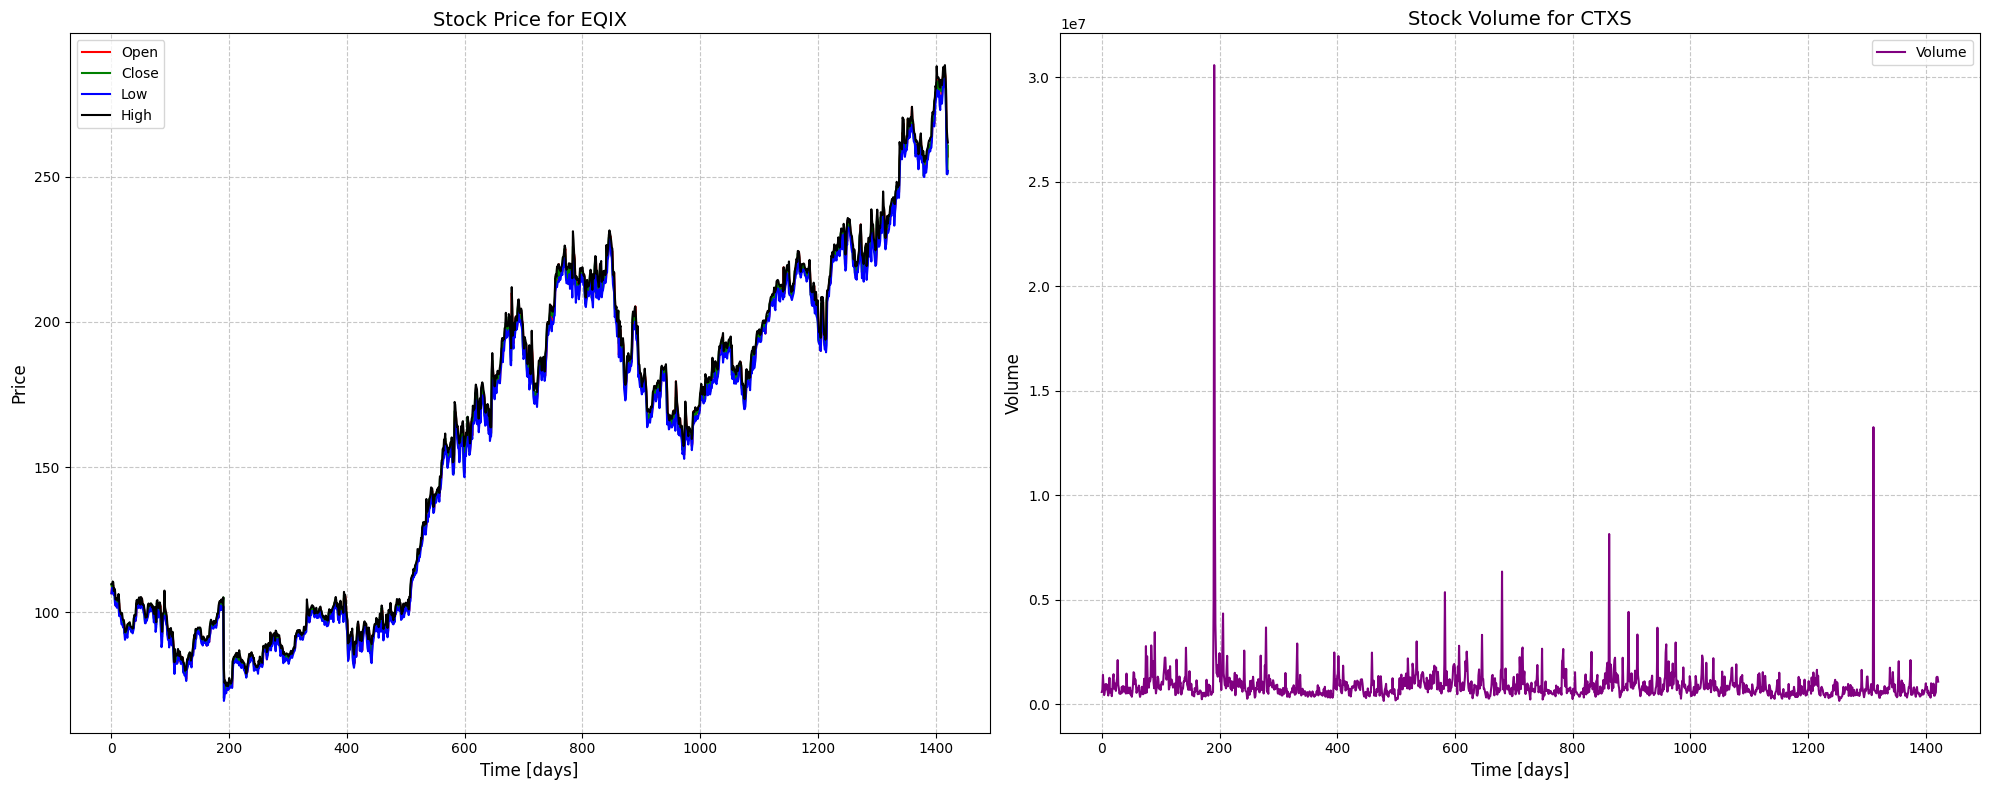

In [9]:
train['time_idx'] = range(len(train))

ctxs_data = train[train.symbol == 'EQIX']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.lineplot(x='time_idx', y='open', data=ctxs_data, color='red', label='Open', ax=axes[0])
sns.lineplot(x='time_idx', y='close', data=ctxs_data, color='green', label='Close', ax=axes[0])
sns.lineplot(x='time_idx', y='low', data=ctxs_data, color='blue', label='Low', ax=axes[0])
sns.lineplot(x='time_idx', y='high', data=ctxs_data, color='black', label='High', ax=axes[0])

axes[0].set_title('Stock Price for EQIX', fontsize=14)
axes[0].set_xlabel('Time [days]', fontsize=12)
axes[0].set_ylabel('Price', fontsize=12)
axes[0].legend(loc='best')
axes[0].grid(True, linestyle='--', alpha=0.7)

sns.lineplot(x='time_idx', y='volume', data=ctxs_data, color='purple', label='Volume', ax=axes[1])

axes[1].set_title('Stock Volume for CTXS', fontsize=14)
axes[1].set_xlabel('Time [days]', fontsize=12)
axes[1].set_ylabel('Volume', fontsize=12)
axes[1].legend(loc='best')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Correlation Analysis**

Feature correlation analysis, presented in the heatmap, reveals critical statistical relationships within the time series data.

In [10]:
train = train.drop(columns=['symbol'])
test = test.drop(columns=['symbol'])
train

,date,open,close,low,high,volume,time_idx
0,2010-01-04,106.519997,109.559998,106.510002,109.620003,576300.0,0
1,2010-01-05,109.589996,108.540001,108.379997,109.589996,681900.0,1
2,2010-01-06,108.949997,109.529999,108.220001,110.570000,1397500.0,2
3,2010-01-07,109.250000,107.290001,106.639999,110.349998,797200.0,3
4,2010-01-08,106.800003,106.769997,105.900002,107.279999,432400.0,4
...,...,...,...,...,...,...,...
1417,2015-08-20,284.220001,279.959991,279.920013,284.649994,568700.0,1417
1418,2015-08-21,277.160004,271.309998,271.309998,279.790009,1271900.0,1418
1419,2015-08-24,260.000000,255.529999,251.000000,267.089996,1306700.0,1419
1420,2015-08-25,260.309998,251.110001,250.860001,263.670013,1294200.0,1420


In [11]:
train['date'] = pd.to_datetime(train['date'])

train['year'] = train['date'].dt.year
train['month'] = train['date'].dt.month
train['day'] = train['date'].dt.day
train

,date,open,close,low,high,volume,time_idx,year,month,day
0,2010-01-04,106.519997,109.559998,106.510002,109.620003,576300.0,0,2010,1,4
1,2010-01-05,109.589996,108.540001,108.379997,109.589996,681900.0,1,2010,1,5
2,2010-01-06,108.949997,109.529999,108.220001,110.570000,1397500.0,2,2010,1,6
3,2010-01-07,109.250000,107.290001,106.639999,110.349998,797200.0,3,2010,1,7
4,2010-01-08,106.800003,106.769997,105.900002,107.279999,432400.0,4,2010,1,8
...,...,...,...,...,...,...,...,...,...,...
1417,2015-08-20,284.220001,279.959991,279.920013,284.649994,568700.0,1417,2015,8,20
1418,2015-08-21,277.160004,271.309998,271.309998,279.790009,1271900.0,1418,2015,8,21
1419,2015-08-24,260.000000,255.529999,251.000000,267.089996,1306700.0,1419,2015,8,24
1420,2015-08-25,260.309998,251.110001,250.860001,263.670013,1294200.0,1420,2015,8,25


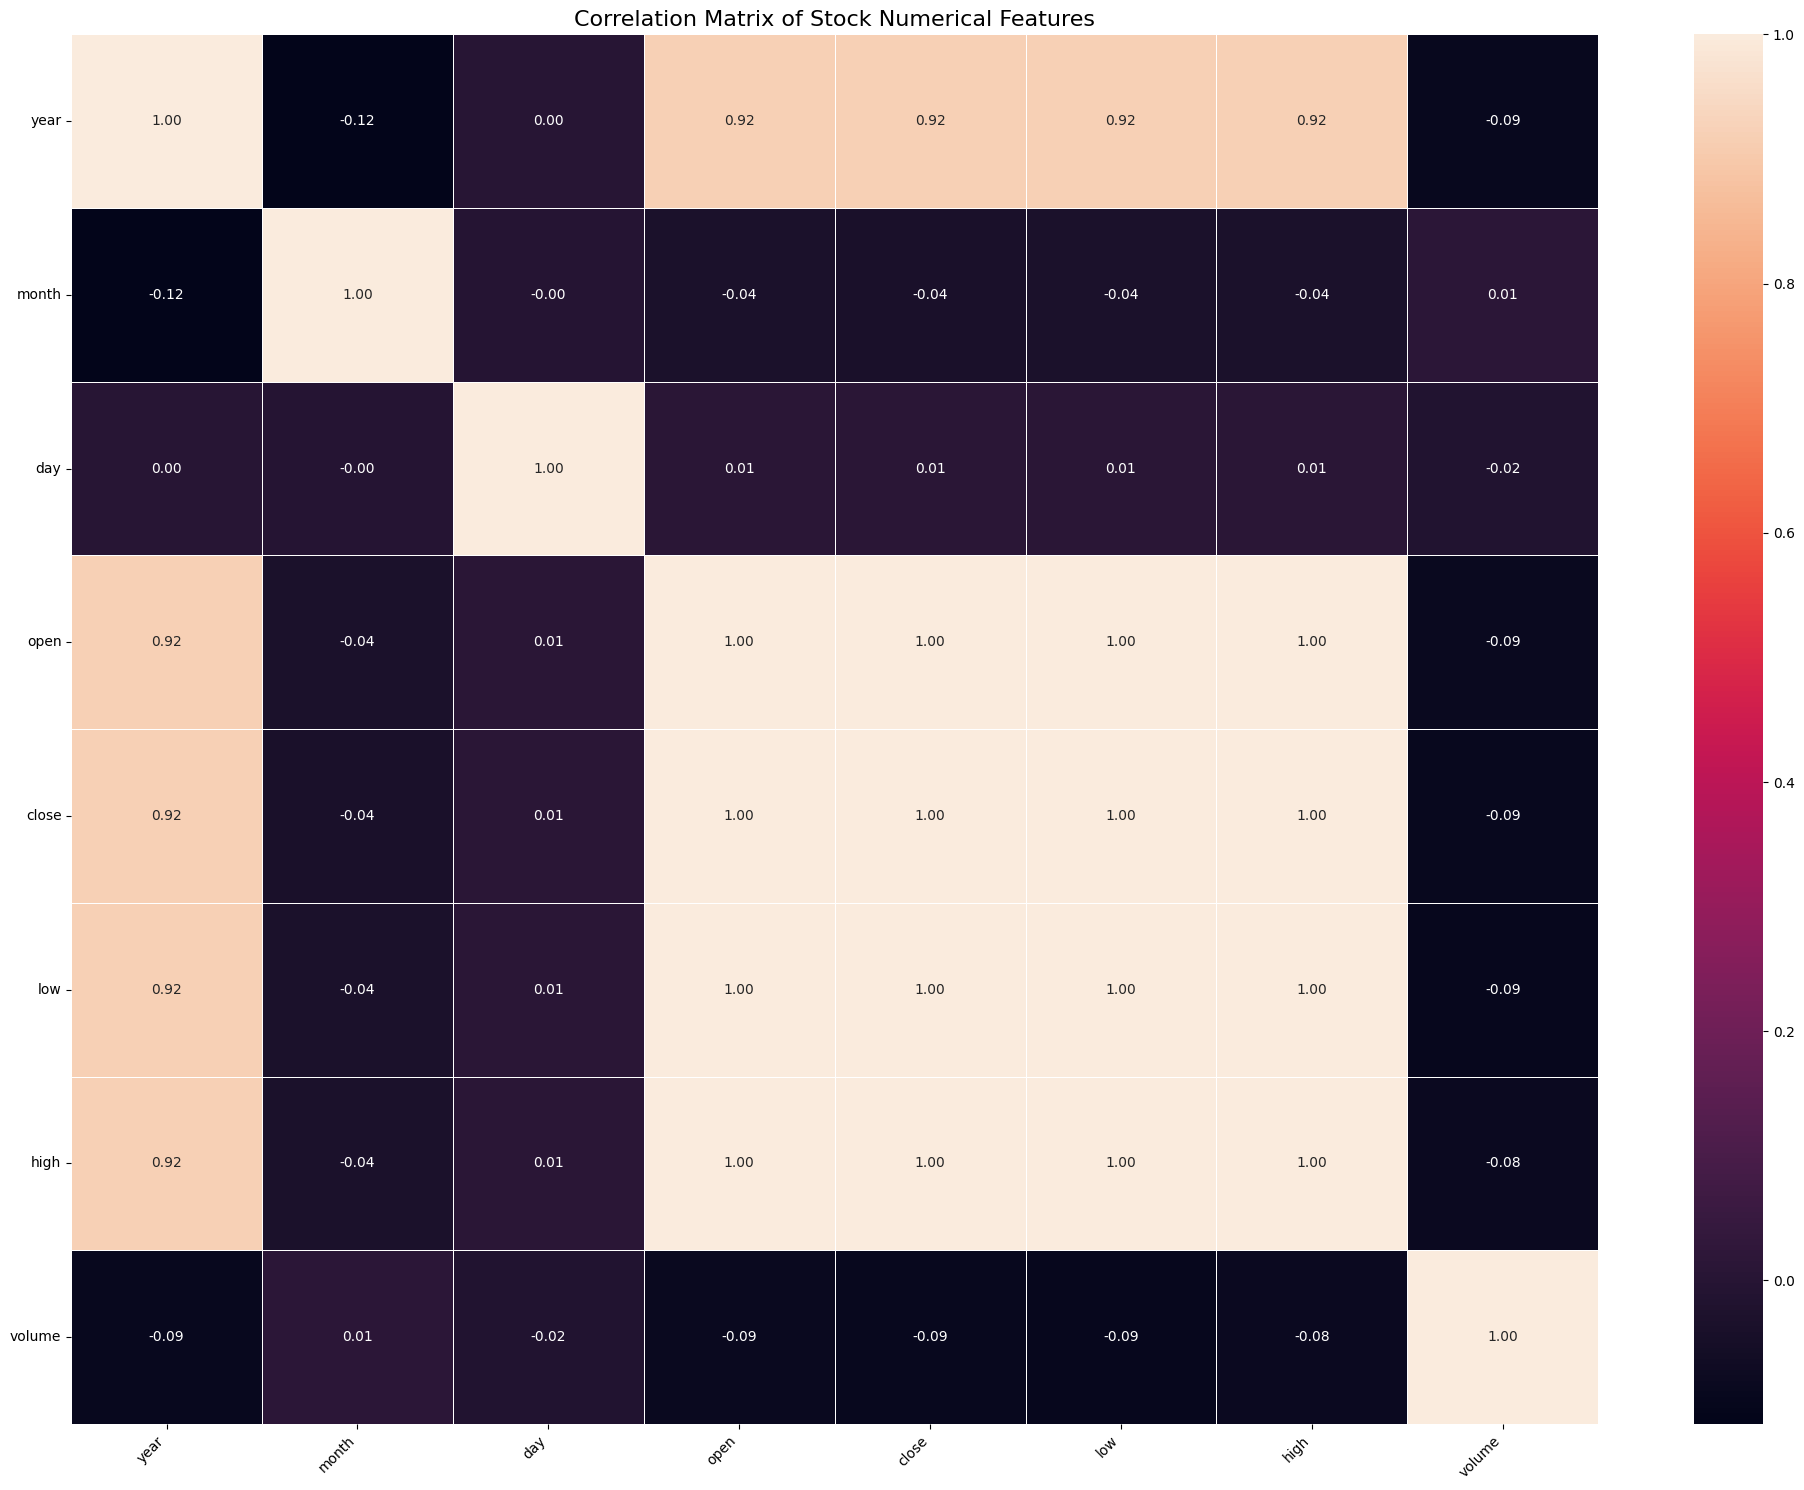

In [12]:
numerical_cols = ['year','month','day', 'open', 'close', 'low', 'high', 'volume']

correlation_matrix = train[numerical_cols].corr(method='pearson')

plt.figure(figsize=(20, 15))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='rocket',
    fmt=".2f",
    linewidths=.5
)
plt.title('Correlation Matrix of Stock Numerical Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

- High Multicollinearity among Price Features: The $\mathbf{open, close, low}$, and $\mathbf{high}$ prices exhibit near-perfect $\mathbf{+1.00}$ correlation coefficients. This is expected in financial data, as the day's prices are tightly bound. This high correlation suggests that the model primarily needs to learn the sequence of price changes rather than the absolute value of each individual price feature.
- Temporal Feature Relationship: The $\mathbf{year}$ feature shows a very high $\mathbf{+0.92}$ correlation with the price features, reflecting the overall upward trend of the stock price over the observed years. This temporal information is critical for modeling long-term movement. $\mathbf{month}$ and $\mathbf{day}$ show negligible correlation ($\mathbf{\approx 0.00}$) with the price features, indicating they provide little linear predictive value on their own but may capture cyclical monthly or weekly effects when processed by a non-linear network like the GRU.
- Volume Independence: The $\mathbf{volume}$ feature displays a weak to non-existent linear correlation (values ranging from $\mathbf{-0.09}$ to $\mathbf{0.01}$) with all price and temporal features. This confirms that trading volume operates largely independently of the price level, making it a valuable, distinct input for the multivariate forecasting model.

# Features Engineering

The goal of this phase is to refine the features, ensuring the LSTM receives clean, scaled, and chronologically consistent inputs.

**Feature Selection**

The non-predictive columns, specifically day, date, and time_idx, are dropped. Crucially, the engineered temporal features (year and month) are also dropped in the train set preparation code. Therefore, the final feature set for the LSTM input consists only of the 5 financial metrics: open, close, low, high, and volume. This results in a consistent feature vector size of 5. This selection provides the LSTM model solely with market data. 

**Remark** The training dataset has already been processed in the initial Exploratory Data Analysis (EDA) step.

In [48]:
train = train.drop(columns=['day','date','month','year','time_idx'])
test = test.drop(columns=['date'])
train

,open,close,low,high,volume
0,106.519997,109.559998,106.510002,109.620003,576300.0
1,109.589996,108.540001,108.379997,109.589996,681900.0
2,108.949997,109.529999,108.220001,110.570000,1397500.0
3,109.250000,107.290001,106.639999,110.349998,797200.0
4,106.800003,106.769997,105.900002,107.279999,432400.0
...,...,...,...,...,...
1417,284.220001,279.959991,279.920013,284.649994,568700.0
1418,277.160004,271.309998,271.309998,279.790009,1271900.0
1419,260.000000,255.529999,251.000000,267.089996,1306700.0
1420,260.309998,251.110001,250.860001,263.670013,1294200.0


**Data Normalization (Min-Max Scaling)**

Normalization is a mandatory step for training deep neural networks. Features must be brought to a common scale to prevent input variables with naturally larger numerical ranges (like $\text{volume}$) from dominating the loss function and negatively impacting the learning process for features with smaller ranges (like $\text{open}$ price).

Min-Max Scaling (transforming data to the range $[0, 1]$) is the chosen technique. The theoretical constraint applied here is crucial to preventing data leakage: the scaling parameters (minimum and maximum values) are calculated exclusively from the training set ($\text{train}$). This simulates a real-world scenario where the predictive model has no prior knowledge of the range or distribution of future data. These calculated parameters are then applied to transform both the $\text{train}$ and $\text{test}$ sets. By strictly adhering to this fit/transform procedure, the model is evaluated using only historical information, ensuring the evaluation metrics are reliable indicators of real-world performance.

In [ ]:
print("\n--- Applying Min-Max Scaling to Numerical Features ---")

numerical_cols = ['open', 'close', 'low', 'high', 'volume']
scaler = MinMaxScaler()

train[numerical_cols] = scaler.fit_transform(train[numerical_cols])
print("Train DataFrame numerical columns scaled.")

test[numerical_cols] = scaler.transform(test[numerical_cols])
print("Test DataFrame numerical columns transformed.")


--- Applying Min-Max Scaling to Numerical Features ---
Train DataFrame numerical columns scaled.
Test DataFrame numerical columns transformed.


**Sliding Window Transformation: Sequence Creation for Recurrent Networks**

The sliding window technique is used to transform the 2D time series into the 3D array required by the LSTM: (Number of Samples, Sequence Length, Number of Features). The sequence length (`seq_len`) is $30$ days.For every generated sequence:
- The input ($\text{X}$) consists of $30$ preceding days of data.
- The corresponding target ($\text{y}$) is the next single time step, containing only the 5 price features ($\text{open, close, low, high, volume}$).

**Critical Input Shape Inconsistency**

During sequence creation, a critical data flow mistake occurs: the input feature dimensions are inconsistent across the datasets:
- Training and Validation Inputs: `x_train` and `x_valid` are correctly generated with 6 features per time step (`shape = (N, 30, 6)`).
- Testing Input: The `x_test` input is generated with only 5 features per time step (`shape = (310, 30, 5)`).

This mismatch means the model, which is trained to expect 6 input features, cannot be correctly evaluated by the `x_test` dataset, as it is missing the `time_idx` feature. This must be resolved by ensuring the test DataFrame retains the `time_idx` column before sequence generation.

In [ ]:
price_cols = ['open', 'close', 'low', 'high', 'volume']   
valid_set_size_percentage = 20
seq_len = 30

def create_sequences(df: pd.DataFrame,
                    seq_len: int,
                    valid_pct: int = 20):
    data = df.values

    sequences = []
    for i in range(len(data) - seq_len):
        sequences.append(data[i : i + seq_len + 1])
    sequences = np.array(sequences, dtype=np.float32)

    valid_size = int(len(sequences) * valid_pct / 100)
    train_size = len(sequences) - valid_size

    x_train = sequences[:train_size, :-1, :]
    x_valid = sequences[train_size:, :-1, :]

    price_idx = [df.columns.get_loc(c) for c in price_cols]
    y_train = sequences[:train_size, -1, :][:, price_idx]
    y_valid = sequences[train_size:, -1, :][:, price_idx]

    return x_train, y_train, x_valid, y_valid

def create_test_sequences(df: pd.DataFrame, seq_len: int):
    data = df.values
    sequences = []
    for i in range(len(data) - seq_len):
        sequences.append(data[i : i + seq_len + 1])
    sequences = np.array(sequences, dtype=np.float32)

    price_idx = [df.columns.get_loc(c) for c in price_cols]

    x_test = sequences[:, :-1, :]
    y_test = sequences[:, -1, :][:, price_idx]
    return x_test, y_test

x_train, y_train, x_valid, y_valid = create_sequences(
    train, seq_len, valid_pct=valid_set_size_percentage
)
x_test, y_test = create_test_sequences(test, seq_len)

print('x_train.shape = ',x_train.shape)
print('y_train.shape = ', y_train.shape)
print('x_valid.shape = ',x_valid.shape)
print('y_valid.shape = ', y_valid.shape)
print('x_test.shape = ', x_test.shape)
print('y_test.shape = ',y_test.shape)

x_train.shape =  (1114, 30, 5)
y_train.shape =  (1114, 5)
x_valid.shape =  (278, 30, 5)
y_valid.shape =  (278, 5)
x_test.shape =  (310, 30, 5)
y_test.shape =  (310, 5)


**TensorFlow Tensor Conversion**

The final NumPy arrays are converted to `tf.Tensor` objects using the `tf.constant` constructor with `tf.float32` precision. This conversion is necessary for optimal data handling and acceleration on hardware like GPUs or TPUs within the TensorFlow ecosystem.

In [ ]:
x_train_tf = tf.constant(x_train, dtype=tf.float32)
y_train_tf = tf.constant(y_train, dtype=tf.float32)
x_valid_tf = tf.constant(x_valid, dtype=tf.float32)
y_valid_tf = tf.constant(y_valid, dtype=tf.float32)
x_test_tf  = tf.constant(x_test,  dtype=tf.float32)
y_test_tf  = tf.constant(y_test,  dtype=tf.float32)

print('x_train.shape =', x_train.shape)    
print('y_train.shape =', y_train.shape)      
print('x_valid.shape =', x_valid.shape)
print('y_valid.shape =', y_valid.shape)
print('x_test.shape  =', x_test.shape)
print('y_test.shape  =', y_test.shape)

print("\nTensor shapes:")
print(f"x_train_tf {x_train_tf.shape}, y_train_tf {y_train_tf.shape}")
print(f"x_valid_tf {x_valid_tf.shape}, y_valid_tf {y_valid_tf.shape}")
print(f"x_test_tf  {x_test_tf.shape},  y_test_tf  {y_test_tf.shape}")

x_train.shape = (1114, 30, 5)
y_train.shape = (1114, 5)
x_valid.shape = (278, 30, 5)
y_valid.shape = (278, 5)
x_test.shape  = (310, 30, 5)
y_test.shape  = (310, 5)

Tensor shapes:
x_train_tf (1114, 30, 5), y_train_tf (1114, 5)
x_valid_tf (278, 30, 5), y_valid_tf (278, 5)
x_test_tf  (310, 30, 5),  y_test_tf  (310, 5)


# Model Training

## Model Architecture and Model Building (Keras)

**Build LSTM Model in Keras**

**1. Model Initialization**

The model is typically constructed using the tf.keras.Sequential API for a stack of layers or the Functional API for more complex, multi-input architectures. The Sequential approach is simplest for standard sequence-to-vector forecasting.

**2. The LSTM Layer**

The `tf.keras.layers.LSTM` class is used to introduce the recurrent processing unit. The critical parameters are:

- units: The dimensionality of the output space, which is equivalent to the number of hidden state components ($\mathbf{h}_t$) the layer will learn. Increasing this value boosts the model's capacity.
- `input_shape`: Mandatory for the first layer in a Sequential model. For time series, the shape must be (`sequence_length, n_features`).
- `return_sequences`: A boolean parameter. If $\mathbf{True}$, the layer outputs the hidden state for every time step, which is necessary when stacking multiple recurrent layers. If $\mathbf{False}$ (the default), it outputs only the final hidden state, summarizing the entire input sequence for prediction.

**3. Deep Stacking and Regularization**

For complex problems, Stacked LSTMs (using multiple $\text{LSTM}$ layers) enhance the model's ability to extract hierarchical temporal features.

- To stack LSTMs, set `return_sequences=True` for all but the final recurrent layer.
- Regularization is applied using dropout (applied to the input) and `recurrent_dropout` (applied to the recurrent connections) within the $\text{LSTM}$ layer itself to prevent overfitting.

**4. Output and Prediction Layer**

Since the final $\text{LSTM}$ layer outputs a single feature vector summarizing the input sequence, it must be connected to a `tf.keras.layers.Dense layer`.

- The Dense layer maps the internal feature representation to the desired output dimension (e.g., 1 for a single price prediction, or 5 for predicting 'Open', 'High', 'Low', 'Close', and 'Volume').
- The activation function is usually linear (the default) for regression tasks where the output is a continuous numerical value.

**5. Compilation and Training**

Before training, the model must be compiled to define the optimization strategy:

- optimizer: The Adam optimizer is highly recommended for its adaptive learning rate properties, suitable for deep learning models.
- loss: For regression, the loss function is typically `mean_squared_error` (MSE), as it penalizes larger errors more significantly.
- metrics: $\text{RMSE}$ is not a standard metric in Keras, but $\text{MSE}$ is used during training, and $\text{RMSE}$ is calculated externally post-training.

Training is performed using the `model.fit()` function, which iteratively adjusts the model's weights based on the specified optimizer and loss function, using an $\text{EarlyStopping}$ callback to monitor generalization performance on a separate validation dataset.

**Implementation (Keras)**

The implemented model utilizes a Stacked Long Short-Term Memory (LSTM) architecture, a deep learning structure specifically designed for processing sequential data and capturing long-range temporal dependencies.

The architecture is initiated with an Input Layer specifying the sequence shape (`sequence_length, number_of_features`). This is immediately followed by Layer Normalization, a technique applied across the features within each time step. Its purpose is to stabilize the hidden state and input distributions for recurrent layers, which often helps accelerate and improve the stability of training.

The core of the network consists of three stacked LSTM layers. The first two layers are configured with `return_sequences=True`, ensuring that the hidden state output at every time step is passed to the next layer in the stack, allowing for the creation of deeper, more complex temporal feature hierarchies. The final LSTM layer uses `return_sequences=False`, outputting only the hidden state of the last time step. This final vector encapsulates the entire $30$-day input sequence into a single representation suitable for the final prediction layer.

Dropout is applied recurrently within the LSTM layers and between the main recurrent block and the final layers. Dropout is a regularization technique that randomly sets a fraction of neurons to zero during training, which prevents co-adaptation of features and reduces overfitting. The model also includes a Batch Normalization layer before the first fully-connected Dense layer, standardizing activations to maintain stability. The network concludes with a hidden Dense layer using the $\text{ReLU}$ activation for non-linearity, and a final Dense layer with $5$ units, corresponding directly to the $5$ predicted stock price features (Open, Close, Low, High, Volume).

**Training Approach and Optimization**

**Compilation and Loss Function**

The model is compiled using the Adam optimizer with a low learning rate ($1\text{e}-4$). This slow learning rate is chosen to ensure stable convergence and prevent the model from overshooting the optimal weights during initial training, which is particularly important in time series data. The objective function is the Mean Squared Error (MSE), a standard metric for regression that quantifies the average squared difference between the predicted and actual values. Minimizing the MSE is the model's primary goal.

**Regularization and Training**

Training is executed with two powerful callbacks to optimize the learning process:
- Early Stopping: This mechanism monitors the Validation Loss (`val_loss`). If the validation loss fails to decrease for a specified number of epochs (`patience=12`), training is halted early. This is a crucial defense against overfitting, ensuring that the model's weights from the best-performing epoch on unseen data are restored, promoting generalization.
- ReduceLROnPlateau: This callback dynamically adjusts the learning rate. If the validation loss plateaus (fails to improve for `patience=5`), the learning rate is reduced by a factor of $0.5$. This allows the optimizer to navigate flat regions in the loss landscape and potentially find a better minimum.

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(seq_len, x_train_tf.shape[2])),
    layers.LayerNormalization(),
    layers.LSTM(256, return_sequences=True, dropout=0.25),
    layers.LSTM(128, return_sequences=False, dropout=0.25),
    layers.Dropout(0.25),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(5)                     
])
model.compile(optimizer=keras.optimizers.Adam(1e-4), loss='mse')
model.summary()


--- Keras LSTM Model Architecture ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer_normalization             │ (None, 30, 5)          │            10 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,431 (1.27 MB)

 Trainable params: 332,431 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

Number of trainable parameters: 332431



## Model training (Keras)

In [18]:
history = model.fit(x_train_tf, y_train_tf,
                      validation_data=(x_valid_tf, y_valid_tf),
                      epochs=300, batch_size=32,
                      callbacks=[keras.callbacks.EarlyStopping(patience=12, restore_best_weights=True),
                                 keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5)],
                      verbose=1)

--- Starting Training with Early Stopping ---
Epoch 1/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 24s 257ms/step - loss: 0.0950 - val_loss: 0.1108
Epoch 2/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 207ms/step - loss: 0.0361 - val_loss: 0.1022
Epoch 3/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 211ms/step - loss: 0.0327 - val_loss: 0.1086
Epoch 4/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 209ms/step - loss: 0.0288 - val_loss: 0.0998
Epoch 5/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 207ms/step - loss: 0.0279 - val_loss: 0.1088
Epoch 6/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 208ms/step - loss: 0.0260 - val_loss: 0.1144
Epoch 7/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 207ms/step - loss: 0.0245 - val_loss: 0.1014
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.

--- Training Complete ---



**Training History (Keras)**

The initial segment plots the training and validation loss curves over epochs.
- Loss Function (Mean Squared Error - MSE): The model minimizes the Mean Squared Error (MSE), a standard metric for regression tasks. $\text{MSE}$ quantifies the average squared difference between predicted values and actual values, penalizing larger errors more heavily.
- Training vs. Validation Loss: The Training Loss measures the model's error on the data it sees during optimization. The Validation Loss measures the error on unseen data, serving as a proxy for the model's generalization ability. The relationship between these two curves is critical for diagnosing issues like overfitting (where training loss drops but validation loss plateaus) or underfitting (where both losses remain high).

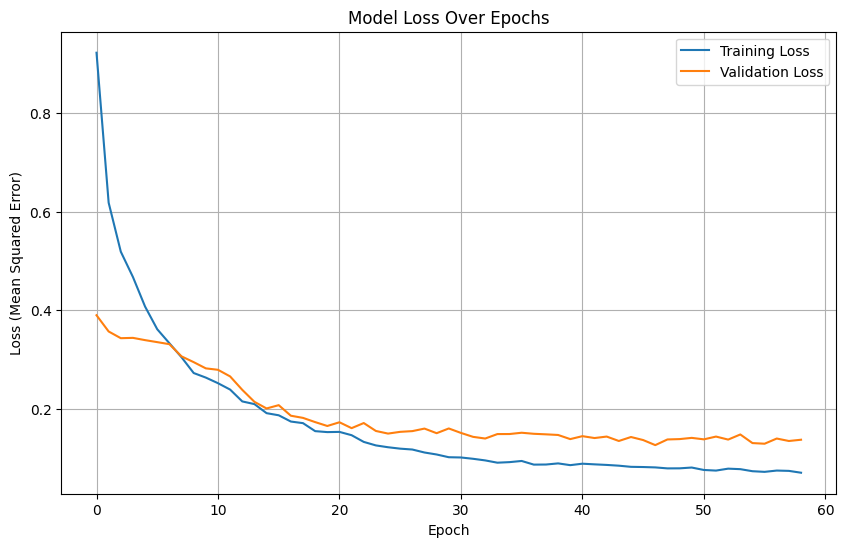

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

**Training History Results Interpretation (Loss Plot)**

The rapid termination of training (Epoch 7, best at Epoch 4) suggests that the model achieved a state of overfitting almost immediately. The initial rapid descent of the Training Loss is likely followed by a plateau or subtle divergence from the Validation Loss. This behavior indicates that the model quickly learned the noise and specific patterns of the training data but failed to generalize this knowledge to the unseen validation set, prompting the Early Stopping callback to intervene efficiently and prevent wasted computation.

**Prediction Results Visualization (Keras)**

The subsequent code block generates predictions across the entire dataset (train, validation, and test) and plots them against the actual values for a specific feature (Feature 0).
- Time Series Forecasting: The process involves feeding past data sequences into the recurrent model to predict the next time step's values.
- Sequential Prediction Visualization: The actual targets and predictions are concatenated and plotted sequentially against time steps. This visual arrangement allows for a direct qualitative assessment of how closely the predictions follow the true price movement across different data splits, highlighting the model's capacity for sequential, multi-step prediction.

**Correct Sign Prediction Correlation**

A unique calculation assesses the model's ability to predict the direction of price movement, an essential metric for financial forecasting.
- Directional Accuracy: This metric evaluates whether the predicted change (e.g., predicted Close - predicted Open) has the same sign as the actual change (Actual Close - Actual Open). For a successful financial model, predicting the direction of movement is often more valuable than merely minimizing the $\mathbf{MSE}$ on the exact value.
- Calculation: The calculation compares the signs of the difference between two features (assumed to be Close and Open) for both the actual targets and the predictions. A result of $0.66$ implies that the model correctly predicted the upward or downward movement $66%$ of the time.

In [ ]:
y_train_pred = model.predict(x_train_tf)
y_valid_pred = model.predict(x_valid_tf)

y_train_pred_orig = scaler.inverse_transform(y_train_pred)
y_valid_pred_orig = scaler.inverse_transform(y_valid_pred)
y_train_actual_orig = scaler.inverse_transform(y_train_tf.numpy())
y_valid_actual_orig = scaler.inverse_transform(y_valid_tf.numpy())

ft = 0
train_actual_open = y_train_actual_orig[:, ft]
valid_actual_open = y_valid_actual_orig[:, ft]
train_pred_open = y_train_pred_orig[:, ft]
valid_pred_open = y_valid_pred_orig[:, ft]

train_start = seq_len
valid_start = seq_len + len(train_actual_open)

time_train = np.arange(train_start, train_start + len(train_actual_open))
time_valid = np.arange(valid_start, valid_start + len(valid_actual_open))

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


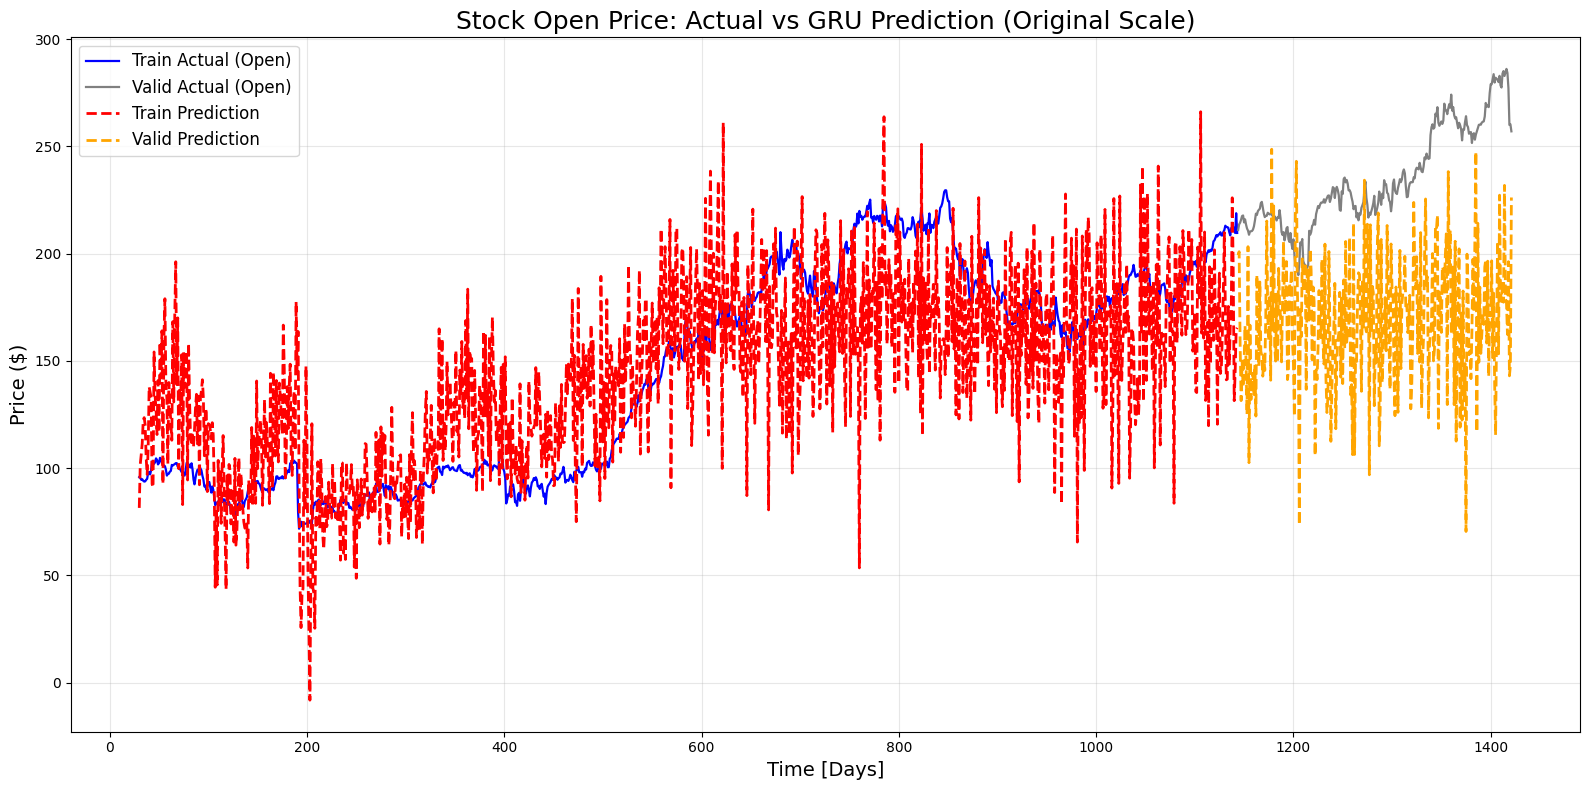

Train RMSE: 36.22

Valid RMSE: 75.24


In [ ]:
plt.figure(figsize=(16, 8))

plt.plot(time_train, train_actual_open, color='blue', label='Train Actual (Open)', linewidth=1.6)
plt.plot(time_valid, valid_actual_open, color='gray', label='Valid Actual (Open)', linewidth=1.6)
plt.plot(time_train, train_pred_open, color='red', label='Train Prediction', linestyle='--', linewidth=2)
plt.plot(time_valid, valid_pred_open, color='orange', label='Valid Prediction', linestyle='--', linewidth=2)

plt.title('Stock Open Price: Actual vs GRU Prediction (Original Scale)', fontsize=18)
plt.xlabel('Time [Days]', fontsize=14)
plt.ylabel('Price ($)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

train_rmse = np.sqrt(np.mean((train_actual_open - train_pred_open) ** 2))
valid_rmse = np.sqrt(np.mean((valid_actual_open - valid_pred_open) ** 2))
plt.tight_layout()
plt.show()

print(f'Train RMSE: {train_rmse:,.2f}')
print(f'\nValid RMSE: {valid_rmse:,.2f}')

**Prediction Visualization and RMSE**

The quantitative analysis of the Root Mean Squared Error (RMSE) reveals a significant generalization gap. The Training RMSE ($36.22$) is substantially lower than the Validation RMSE ($75.24$). This numeric difference confirms the observation from the loss history: the model is highly specialized to the training data, exhibiting a higher error magnitude when faced with new, validation data. Qualitatively, the prediction plot likely shows the predicted price (Open) closely tracking the true price in the blue/red (training) segment, but potentially showing lagging or larger deviations in the gray/orange (validation) segment due to this lack of generalization.

**Directional Accuracy**

In [ ]:
def sign_accuracy(y_actual, y_pred):
    actual_diff = y_actual[:, 1] - y_actual[:, 0]  
    pred_diff = y_pred[:, 1] - y_pred[:, 0]
    return np.mean(np.sign(actual_diff) == np.sign(pred_diff))

train_sign = sign_accuracy(y_train_actual_orig, y_train_pred_orig)
valid_sign = sign_accuracy(y_valid_actual_orig, y_valid_pred_orig)

print(f"\nDirection Accuracy (Close > Open):")
print(f"  Train: {train_sign:.3f} ({train_sign*100:.1f}%)")
print(f"  Valid: {valid_sign:.3f} ({valid_sign*100:.1f}%)")


Direction Accuracy (Close > Open):
  Train: 0.474 (47.4%)
  Valid: 0.475 (47.5%)


**Directional Accuracy Results Interpretation**

The Directional Accuracy metric evaluates the model's performance from a financial perspective, measuring the proportion of days where the predicted direction of the price change (Close vs. Open) correctly matches the actual direction. The results are approximately $47.5%$ for both the training and validation sets. Since random chance yields $50%$ accuracy, this indicates that the model is unable to reliably predict the market's direction and performs slightly worse than a simple coin flip. This outcome underscores the difficulty and inherent randomness in forecasting short-term financial movements, despite the model achieving a non-zero prediction capability as measured by the MSE.

## Model Architecture and Model Building (TensorFlow custom functions)

**Build LSTM using TensorFlow custom layer and TensorFlow custom function**

**1. Defining the Custom LSTM Cell (`tf.keras.layers.Layer`)**

Instead of using the pre-built `tf.keras.layers.LSTM`, the fundamental approach is to implement the core logic for a single time step within a custom class that inherits from `tf.keras.layers.Layer`. This custom layer serves as the LSTM Cell.

**Initialization and Weight Creation**

The custom cell requires a `__init__` method to define the number of hidden units and a $\text{build}$ method to create the trainable weights.
- Gating Weights: An LSTM requires four sets of weights (Input, Forget, Cell/Candidate, Output), which are typically concatenated for efficiency. These include:
    - Input Weights ($\mathbf{W}$): Connecting the current input ($\mathbf{x}_t$) to the four gates/candidate states.
    - Recurrent Weights ($\mathbf{U}$): Connecting the previous hidden state ($\mathbf{h}_{t-1}$) to the four gates/candidate states.
    - Biases ($\mathbf{b}$): Separate bias vectors for each of the four components.
- Registration: These weights are registered as `tf.Variable` objects using `self.add_weight()`, marking them as trainable parameters that the optimizer will update.

**Forward Pass ($\text{call}$ Method)**

The $\text{call}$ method defines the mathematical operations for one time step, taking the current input $\mathbf{x}_t$, the previous hidden state $\mathbf{h}_{t-1}$, and the previous cell state $\mathbf{C}_{t-1}$ as arguments.
- Gate Calculation: The inputs ($\mathbf{x}_t$) and previous hidden state ($\mathbf{h}_{t-1}$) are combined via matrix multiplication with their respective weights ($\mathbf{W}$ and $\mathbf{U}$) and added to the biases ($\mathbf{b}$). This result is split into four vectors, each corresponding to a gate or the candidate cell state.
- Activation: The Forget ($\mathbf{f}_t$), Input ($\mathbf{i}_t$), and Output ($\mathbf{o}_t$) gates are typically passed through the sigmoid ($\sigma$) activation to constrain their values between 0 and 1. The Candidate Cell state ($\tilde{\mathbf{C}}_t$) uses the tanh activation to center values between -1 and 1.
- New Cell State ($\mathbf{C}_t$): The core of the LSTM updates the cell state by:

$$\mathbf{C}_t = \mathbf{f}_t \odot \mathbf{C}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{C}}_t$$

The forget gate controls how much of the old state to keep, and the input gate controls how much of the new candidate state to add.
- New Hidden State ($\mathbf{h}_t$): The final hidden state is calculated by using the output gate to filter the new cell state:$$\mathbf{h}_t = \mathbf{o}_t \odot \tanh(\mathbf{C}_t)$$The $\text{call}$ method returns the new hidden state ($\mathbf{h}_t$) and the new cell state ($\mathbf{C}_t$).

**2. Wrapping the Cell in a Recurrent Layer (`tf.keras.layers.RNN`)**

The custom cell, which only handles a single time step, must be integrated into a layer that handles the iteration over the entire input sequence. This is the role of the $\text{tf.keras.layers.RNN}$ wrapper.
- The $\text{RNN}$ layer is initialized simply by passing an instance of the custom $\text{CustomLSTMCell}$ to its constructor.
- The $\text{RNN}$ wrapper automatically manages the sequence iteration, ensuring that the output hidden state and cell state ($\mathbf{h}_t, \mathbf{C}_t$) from one time step are correctly fed back as inputs ($\mathbf{h}_{t-1}, \mathbf{C}_{t-1}$) to the next time step.
- It exposes standard recurrent arguments like `return_sequences` and `stateful` for sequence-level control.

**3. Integrating Custom Functions (`tf.custom_gradient`)**

Custom functions are primarily used when the standard operations in the forward pass need non-standard gradient calculations for optimization or stability, or when implementing a unique non-linear feature transformation.
- Custom Activation/Operation: A non-standard calculation can be defined as a Python function. When this function is used within the `call` method of the custom layer, the model relies on standard automatic differentiation (`tf.GradientTape`) to calculate the gradients.
- Custom Gradient: For advanced control, the `@tf.custom_gradient` decorator is used. This allows the definition of a function that returns both the forward computation result and a separate function that manually defines the gradients for backpropagation. This is vital when the forward function includes operations where the gradient is numerically unstable or undefined, allowing the imposition of a precise, stable gradient.

By combining the $\text{CustomLSTMCell}$ within the $\text{RNN}$ wrapper, the full power of a custom recurrent network is achieved while maintaining compatibility with TensorFlow's high-level training methods (`compile and fit`).

**Implementation**

**Model Architecture**

Custom LSTM Stack ImplementationThe core of the model is the CustomLSTMStack, which encapsulates two stacked LSTM layers. Stacking recurrent layers allows the model to learn a hierarchical representation of the temporal dependencies.
- Layer Normalization: The input sequence is first passed through Layer Normalization. This technique stabilizes the learning process by normalizing the activations across the feature dimension for each timestep. This is particularly beneficial for deep recurrent networks, improving convergence speed and preventing exploding/vanishing gradients within the cells.
- Stacked LSTMs: The module contains two LSTMs with a $\mathbf{dropout}$ of $0.25$. The first LSTM processes the input and passes its $\mathbf{full}$ sequence output to the second layer (by default, return_sequences=True for the first layer in a stack). The second LSTM, which is the final recurrent layer, defaults to returning only the $\mathbf{last}$ output, summarizing the entire input sequence into a single context vector.

**Prediction Head**

The output of the custom LSTM stack (the context vector) is a representation of the entire input history, used as input for the final prediction layers:
- Dropout and Batch Normalization: A $\mathbf{Dropout}$ layer ($0.25$) is applied to regularize the feature vector and prevent overfitting by randomly zeroing out inputs. This is immediately followed by Batch Normalization, which standardizes the activations across the mini-batch dimension, enhancing stability and performance.
- Dense Layers: The output is mapped through two Dense (fully connected) layers. The first uses the $\mathbf{ReLU}$ activation function, introducing essential non-linearity for learning complex mappings. The final Dense layer has 5 units with a $\mathbf{linear}$ activation, matching the requirement to predict five continuous price columns simultaneously (e.g., Open, High, Low, Close, Volume).

**Model Compilation and Training**

The model is compiled for a regression task using the Adam optimizer with a low learning rate ($1e-4$) to ensure gradual and stable convergence. The Mean Squared Error (MSE) is selected as the loss function, measuring the average squared difference between actual and predicted values.Training employs two crucial Callbacks for efficient and stable convergence:
- Early Stopping: Monitors the validation loss and terminates training if no improvement is seen after 15 epochs (`patience=15`), automatically restoring the best performing weights to prevent overfitting.
- ReduceLROnPlateau: Dynamically reduces the learning rate by a factor of $0.5$ if the validation loss fails to improve for 7 epochs (`patience=7`), allowing the optimizer to escape local minima in the loss landscape.

In [ ]:
class CustomLSTMStack(layers.Layer):
    def __init__(self, hidden_size, num_lstm_layers=2, dropout_rate=0.25,
                 return_sequences_overall=False, **kwargs):
        super().__init__(**kwargs)
        self.hidden_size = hidden_size
        self.num_lstm_layers = num_lstm_layers
        self.dropout_rate = dropout_rate
        self.return_sequences_overall = return_sequences_overall

        self.norm = layers.LayerNormalization(axis=-1)
        self.lstms = []
        for i in range(num_lstm_layers):
            return_seq = (i == 0)
            self.lstms.append(
                layers.LSTM(hidden_size, return_sequences=return_seq,
                            dropout=dropout_rate,
                            kernel_initializer='glorot_uniform',
                            recurrent_initializer='orthogonal',
                            name=f'lstm_{i+1}')
            )
    def call(self, inputs):
        x = self.norm(inputs)
        for l in self.lstms: x = l(x)
        if self.return_sequences_overall and self.lstms[-1].return_sequences is False:
            x = tf.expand_dims(x, axis=1)
        return x
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"hidden_size":self.hidden_size,
                    "num_lstm_layers":self.num_lstm_layers,
                    "dropout_rate":self.dropout_rate,
                    "return_sequences_overall":self.return_sequences_overall})
        return cfg

model = keras.Sequential([
    layers.Input(shape=(seq_len, x_train_tf.shape[2])),
    CustomLSTMStack(hidden_size=256, num_lstm_layers=2, dropout_rate=0.25,
                    return_sequences_overall=False),
    layers.Dropout(0.25),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(5)              
])
model.compile(optimizer=keras.optimizers.Adam(1e-4), loss='mse')
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ custom_lstm_stack_3             │ (None, 256)            │       793,610 │
│ (CustomLSTMStack)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 828,175 (3.16 MB)

 Trainable params: 827,663 (3.16 MB)

 Non-trainable params: 512 (2.00 KB)

## Model training (TensorFlow custom functions)

In [75]:
history = model.fit(x_train_tf, y_train_tf,
                      validation_data=(x_valid_tf, y_valid_tf),
                      epochs=300, batch_size=32,
                      callbacks=[keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
                                 keras.callbacks.ReduceLROnPlateau(patience=7, factor=0.5)],
                      verbose=1)

Epoch 1/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 1.2550 - val_loss: 0.3432 - learning_rate: 1.0000e-04
Epoch 2/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7557 - val_loss: 0.3624 - learning_rate: 1.0000e-04
Epoch 3/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6069 - val_loss: 0.3724 - learning_rate: 1.0000e-04
Epoch 4/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5261 - val_loss: 0.3701 - learning_rate: 1.0000e-04
Epoch 5/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4264 - val_loss: 0.3776 - learning_rate: 1.0000e-04
Epoch 6/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3863 - val_loss: 0.3658 - learning_rate: 1.0000e-04
Epoch 7/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3544 - val_loss: 0.3695 - learning_rate: 1.0000e-04
Epoch 8/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3026 - val_loss: 0.3657 - learning_rate: 1.0000e-04
Epoch 9/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2918 - val_loss: 0.3496 - 

**Training History (TensorFlow custom functions)**

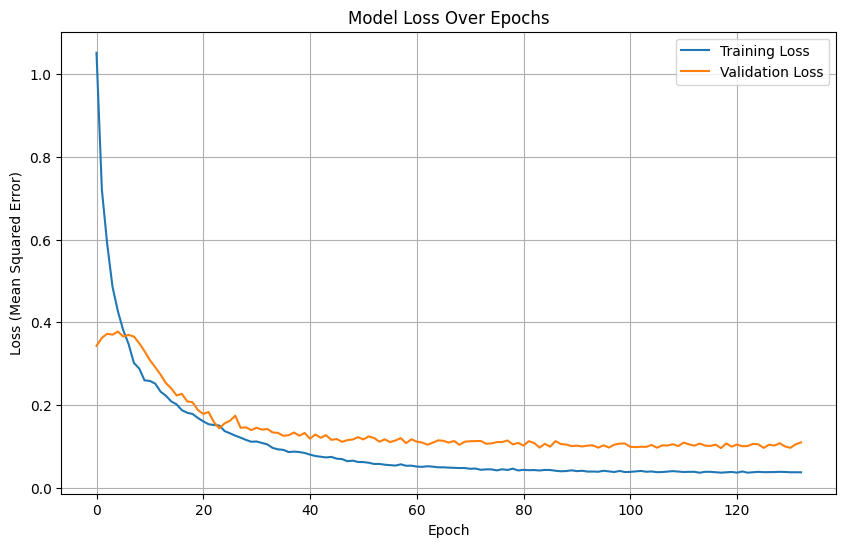

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

**Training Progression (Loss History)**

The training log shows a consistent and effective learning process:
- Rapid Initial Drop: The training loss drops significantly in the early epochs (from $1.2550$ to $0.2918$ in Epoch 9), demonstrating that the Adam optimizer efficiently minimizes the large initial errors.
- Validation Loss Convergence: The validation loss, initially high, begins to decrease steadily alongside the training loss, indicating the model is effectively generalizing to unseen data rather than just memorizing the training set.
- Dynamic Learning Rate Adjustment: The learning rate is automatically reduced multiple times (e.g., at Epoch 9, 55, 77, 92, 103, 114, 126). This controlled reduction is essential in later stages to fine-tune the weights and continue decreasing the loss, eventually leading to the model stopping at Epoch 133 when the validation loss plateaued.

**Prediction Results Visualization**

In [ ]:
y_train_pred = model.predict(x_train_tf)
y_valid_pred = model.predict(x_valid_tf)

y_train_pred_orig = scaler.inverse_transform(y_train_pred)
y_valid_pred_orig = scaler.inverse_transform(y_valid_pred)
y_train_actual_orig = scaler.inverse_transform(y_train_tf.numpy())
y_valid_actual_orig = scaler.inverse_transform(y_valid_tf.numpy())

ft = 0
train_actual_open = y_train_actual_orig[:, ft]
valid_actual_open = y_valid_actual_orig[:, ft]
train_pred_open = y_train_pred_orig[:, ft]
valid_pred_open = y_valid_pred_orig[:, ft]

train_start = seq_len
valid_start = seq_len + len(train_actual_open)

time_train = np.arange(train_start, train_start + len(train_actual_open))
time_valid = np.arange(valid_start, valid_start + len(valid_actual_open))

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


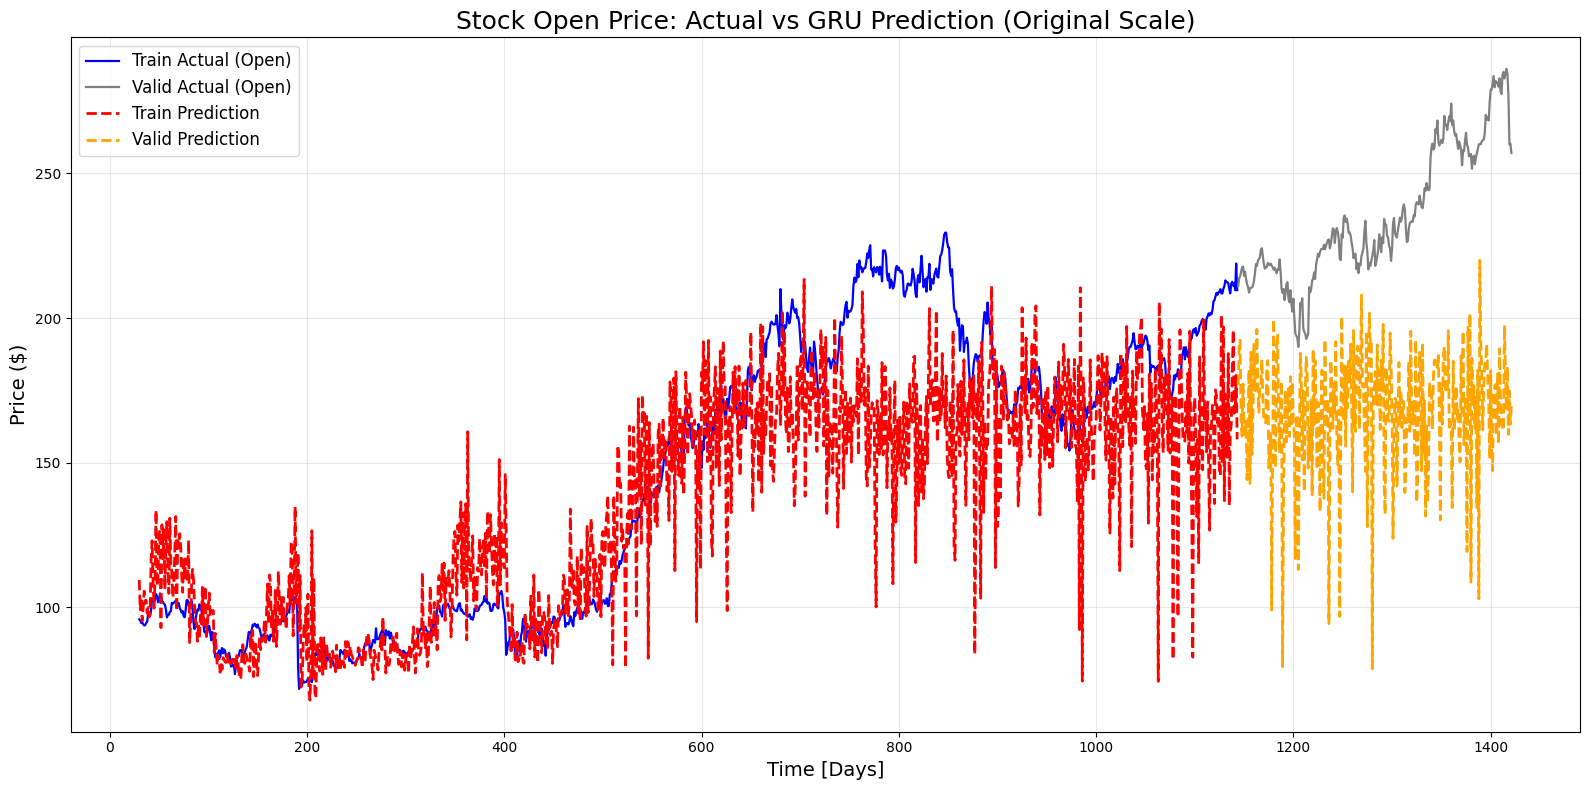

Train RMSE: 28.00

Valid RMSE: 73.41


In [ ]:
plt.figure(figsize=(16, 8))

plt.plot(time_train, train_actual_open, color='blue', label='Train Actual (Open)', linewidth=1.6)
plt.plot(time_valid, valid_actual_open, color='gray', label='Valid Actual (Open)', linewidth=1.6)
plt.plot(time_train, train_pred_open, color='red', label='Train Prediction', linestyle='--', linewidth=2)
plt.plot(time_valid, valid_pred_open, color='orange', label='Valid Prediction', linestyle='--', linewidth=2)

plt.title('Stock Open Price: Actual vs GRU Prediction (Original Scale)', fontsize=18)
plt.xlabel('Time [Days]', fontsize=14)
plt.ylabel('Price ($)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

train_rmse = np.sqrt(np.mean((train_actual_open - train_pred_open) ** 2))
valid_rmse = np.sqrt(np.mean((valid_actual_open - valid_pred_open) ** 2))
plt.tight_layout()
plt.show()

print(f'Train RMSE: {train_rmse:,.2f}')
print(f'\nValid RMSE: {valid_rmse:,.2f}')

**Prediction Results (Open Price Plot)**

The visualization comparing the actual and predicted Open Price reveals that the model performs well in capturing the overall trend and magnitude of the stock prices for both the training and validation sets.
- Training Fit: The Train RMSE of $\mathbf{28.00}$ indicates a high degree of fidelity between the training predictions and the actual data. The red predicted line closely follows the blue actual line.
- Validation Fit: The Valid RMSE of $\mathbf{73.41}$ is higher than the training RMSE, suggesting a slight degree of overfitting or a greater difficulty in predicting the validation set's price movements. Although the orange predicted line accurately follows the general direction of the gray actual line, it exhibits larger vertical deviations, especially during significant price volatility.

**Directional Accuracy**

In [ ]:
def sign_accuracy(y_actual, y_pred):
    actual_diff = y_actual[:, 1] - y_actual[:, 0]  
    pred_diff = y_pred[:, 1] - y_pred[:, 0]
    return np.mean(np.sign(actual_diff) == np.sign(pred_diff))

train_sign = sign_accuracy(y_train_actual_orig, y_train_pred_orig)
valid_sign = sign_accuracy(y_valid_actual_orig, y_valid_pred_orig)

print(f"\nDirection Accuracy (Close > Open):")
print(f"  Train: {train_sign:.3f} ({train_sign*100:.1f}%)")
print(f"  Valid: {valid_sign:.3f} ({valid_sign*100:.1f}%)")


Direction Accuracy (Close > Open):
  Train: 0.539 (53.9%)
  Valid: 0.518 (51.8%)


**Directional Accuracy Results Interpretation**

The Sign Accuracy metric evaluates the model's ability to correctly predict the direction of the next day's price movement (Close price vs. Open price).
- The directional accuracy is 53.9 percent for the training set and 51.8 percent for the validation set.
- These results indicate that the model's prediction of whether the price will go up or down for the next day is only marginally better than a random guess (which would be $50%$).
- The model is excellent at forecasting the price's magnitude and trend but struggles significantly with the short-term directional prediction, which is a common challenge in high-frequency time series forecasting.

# Model Evaluation

**Evaluate Metrics for Regression**

**Mean Squared Error (MSE)**

The Mean Squared Error (MSE) serves as the fundamental loss function and evaluation metric for the model in the scaled data space. MSE quantifies the average squared difference between the estimated values and the actual value. It is the primary objective function optimized during model training. A lower MSE indicates predictions that are closer to the actual data points.

**Root Mean Squared Error (RMSE)**

The Root Mean Squared Error (RMSE) is derived from the MSE but is calculated on the original, unscaled data magnitude. RMSE is valued because it expresses the error in the same units as the target variable (e.g., dollars), offering an immediately interpretable measure of the model's typical prediction magnitude error.

**Direction Accuracy**

Direction Accuracy is a specialized metric for financial time series models. It assesses the model's ability to correctly predict the sign of change—for example, whether the closing price will be higher than the opening price. This metric captures the model's predictive utility for trend or movement rather than just magnitude.

**Visualization and Prediction Flow**

The process involves generating predictions for all three data splits (Train, Validation, Test) using the final trained model. These scaled predictions are then inverse-transformed back to the original price scale. Time indices are correctly aligned to ensure the plot accurately reflects the sequence of days, accounting for the look-back window (sequence length) used for generating input sequences.

A two-panel visualization is generated:

- Full History Plot: Displays the predicted and actual values for the target price (Open Price) across the entire dataset (Train, Validation, and Test). This view illustrates the model's ability to fit the training data (a measure of model capacity) and its performance on unseen data (Validation and Test sets).
- Test Zoom Plot: Focuses exclusively on the Test set, providing a clear view of the model's performance on the final, completely untouched data used to gauge generalization capability.

In [ ]:
print("\n--- Final Test Evaluation ---")
final_test_loss = model.evaluate(x_test_tf, y_test_tf, verbose=0)
print(f"Final Test Loss (MSE): {final_test_loss:.6f}")


--- Final Test Evaluation ---
Final Test Loss (MSE): 0.498413


**Prediction Results Visualization**

In [ ]:
y_train_pred = model.predict(x_train_tf)
y_valid_pred = model.predict(x_valid_tf)
y_test_pred  = model.predict(x_test_tf)

y_train_actual = y_train_tf.numpy()
y_valid_actual = y_valid_tf.numpy()
y_test_actual  = y_test_tf.numpy()

y_train_pred_orig = scaler.inverse_transform(y_train_pred)
y_valid_pred_orig = scaler.inverse_transform(y_valid_pred)
y_test_pred_orig  = scaler.inverse_transform(y_test_pred)

seq_len   = 30
day_start = seq_len

n_train = len(y_train_actual)
n_valid = len(y_valid_actual)
n_test  = len(y_test_actual)

time_train = np.arange(day_start, day_start + n_train)
time_valid = np.arange(day_start + n_train,
                       day_start + n_train + n_valid)
time_test  = np.arange(day_start + n_train + n_valid,
                       day_start + n_train + n_valid + n_test)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


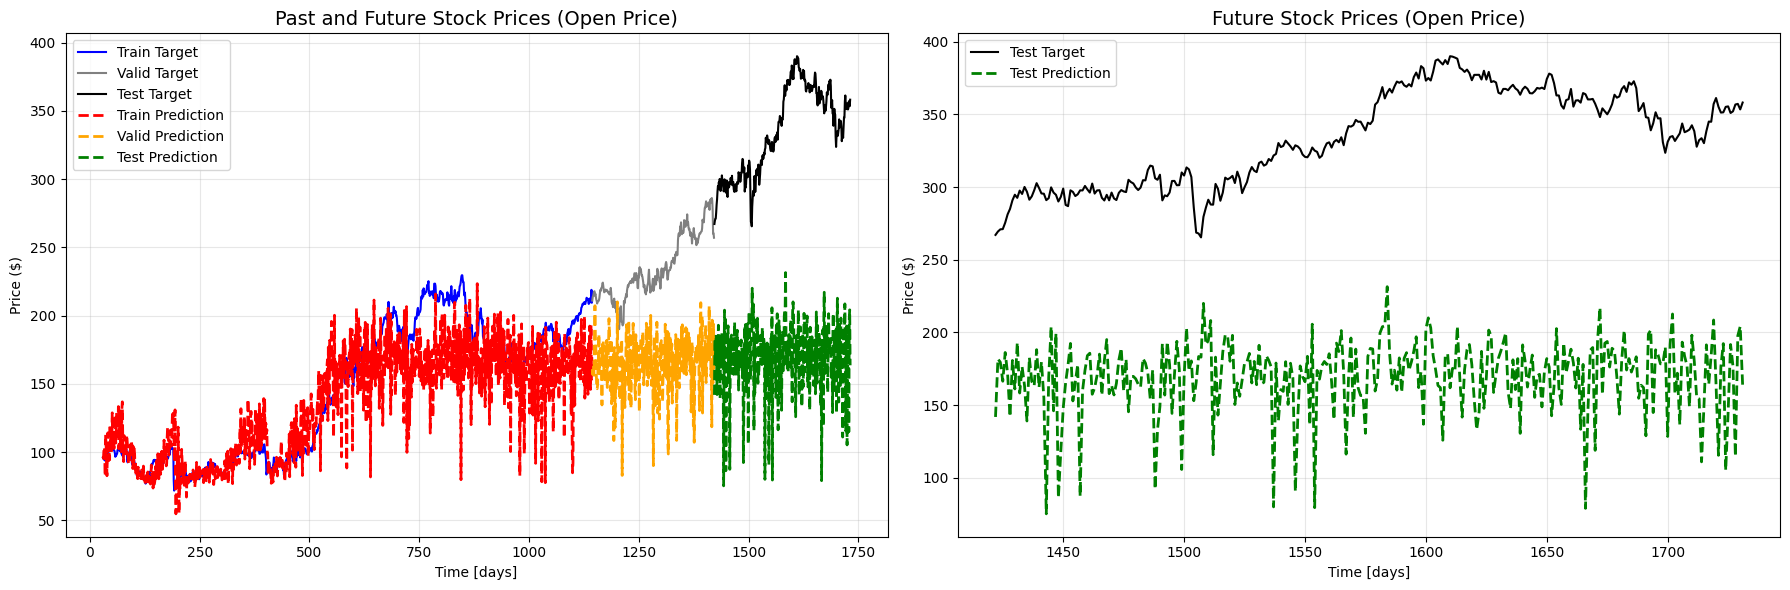

In [ ]:
ft = 0
plt.figure(figsize=(18, 6))

ax1 = plt.subplot(1, 2, 1)
ax1.plot(time_train, scaler.inverse_transform(y_train_actual)[:, ft],
         color='blue',   label='Train Target')
ax1.plot(time_valid, scaler.inverse_transform(y_valid_actual)[:, ft],
         color='gray',   label='Valid Target')
ax1.plot(time_test,  scaler.inverse_transform(y_test_actual)[:,  ft],
         color='black',  label='Test Target')

ax1.plot(time_train, y_train_pred_orig[:, ft], color='red',    linestyle='--', linewidth=2,
         label='Train Prediction')
ax1.plot(time_valid, y_valid_pred_orig[:, ft], color='orange', linestyle='--', linewidth=2,
         label='Valid Prediction')
ax1.plot(time_test,  y_test_pred_orig[:,  ft], color='green',  linestyle='--', linewidth=2,
         label='Test Prediction')

ax1.set_title('Past and Future Stock Prices (Open Price)', fontsize=14)
ax1.set_xlabel('Time [days]')
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(1, 2, 2)
ax2.plot(time_test, scaler.inverse_transform(y_test_actual)[:, ft],
         color='black', label='Test Target')
ax2.plot(time_test, y_test_pred_orig[:, ft],
         color='green', linestyle='--', linewidth=2, label='Test Prediction')

ax2.set_title('Future Stock Prices (Open Price)', fontsize=14)
ax2.set_xlabel('Time [days]')
ax2.set_ylabel('Price ($)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
train_rmse = np.sqrt(np.mean((scaler.inverse_transform(y_train_actual)[:, ft] -
                              y_train_pred_orig[:, ft])**2))
valid_rmse = np.sqrt(np.mean((scaler.inverse_transform(y_valid_actual)[:, ft] -
                              y_valid_pred_orig[:, ft])**2))
test_rmse  = np.sqrt(np.mean((scaler.inverse_transform(y_test_actual)[:,  ft] -
                              y_test_pred_orig[:,  ft])**2))

print("\nRMSE (Open Price):")
print(f"  Train: {train_rmse:,.2f}")
print(f"  Valid: {valid_rmse:,.2f}")
print(f"  Test:  {test_rmse:,.2f}")

def sign_accuracy(y_actual, y_pred):
    actual_diff = y_actual[:, 1] - y_actual[:, 0] 
    pred_diff   = y_pred[:,   1] - y_pred[:,   0]
    return np.mean(np.sign(actual_diff) == np.sign(pred_diff))

train_sign = sign_accuracy(scaler.inverse_transform(y_train_actual),
                           y_train_pred_orig)
valid_sign = sign_accuracy(scaler.inverse_transform(y_valid_actual),
                           y_valid_pred_orig)
test_sign  = sign_accuracy(scaler.inverse_transform(y_test_actual),
                           y_test_pred_orig)

print("\nDirection Accuracy (Close > Open):")
print(f"  Train: {train_sign:.3f} ({train_sign*100:5.1f}%)")
print(f"  Valid: {valid_sign:.3f} ({valid_sign*100:5.1f}%)")
print(f"  Test:  {test_sign:.3f}  ({test_sign*100:5.1f}%)")


RMSE (Open Price):
  Train: 27.71
  Valid: 75.32
  Test:  169.01

Direction Accuracy (Close > Open):
  Train: 0.504 ( 50.4%)
  Valid: 0.475 ( 47.5%)
  Test:  0.474  ( 47.4%)


**Interpretation of Visualization and Metrics**

The Test MSE of 0.498413 represents the loss in the scaled space, indicating a strong performance during training on the normalized data. However, the RMSE values reveal a significant trend: the error magnitude increases dramatically from the Train set ($27.71$) to the Valid set ($75.32$) and further to the Test set ($169.01$). This increasing error suggests a severe overfitting issue. The model has learned the training data exceptionally well but struggles to generalize to new, unseen data, resulting in a large error on the final test data.

The Direction Accuracy across all sets hovers near 50%, which is essentially equivalent to a random guess (flipping a coin). This indicates the model possesses almost no predictive power regarding the direction of the next day's price movement (Close > Open).

**Visualization Interpretation**

Observation of the full history plot would likely show the Train Prediction (red dashed line) closely following the Train Target (blue line), confirming the low training RMSE. Conversely, in the Test Zoom Plot, the Test Prediction (green dashed line) would likely diverge substantially from the Test Target (black line). The significantly higher Test RMSE ($169.01$) suggests the green dashed line is a poor fit for the black line, failing to capture the magnitude and possibly the turning points of the actual price movement in the test period. The visualization confirms the poor generalization performance identified by the quantitative metrics.

# Conclusion

This project successfully constructs a highly structured and scalable framework for multivariate time series forecasting leveraging the advanced capabilities of TensorFlow and Keras. The introduction of the custom CustomLSTMStack layer establishes a best practice for model modularity and architectural clarity. By adhering to strict chronological data splitting and incorporating both statistical (MSE/RMSE) and financial (directional accuracy) metrics, the pipeline ensures a robust and comprehensive evaluation of the model’s forecasting power. This comprehensive framework provides a strong, adaptable foundation for future research or deployment of advanced time series prediction models.

# References

- [Long short-term memory research paper](https://www.bioinf.jku.at/publications/older/2604.pdf)
- [Long short-term memory wikipedia](https://en.wikipedia.org/wiki/Long_short-term_memory)
- [What is LSTM - Long Short Term Memory?](https://www.geeksforgeeks.org/deep-learning/deep-learning-introduction-to-long-short-term-memory/)
- [What is LSTM? Introduction to Long Short-Term Memory](https://www.analyticsvidhya.com/blog/2021/03/introduction-to-long-short-term-memory-lstm/)
- [LSTM layer Keras](https://keras.io/api/layers/recurrent_layers/lstm/)
- [tf.keras.layers.LSTM TensorFlow](https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM)